# Annual thirstwave metrics

## Config and functions

In [8]:
import scienceplots
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '../') # Trick to import code from parent library
import cmip6_archive as ca

In [9]:
# Root folder where thirstwave metrics files are stored
BASEDIR = Path("/work10/archive/CMIP6/CMIP-SSPs/thirstwave_detection/thirstwave_features")

# Names of the 8 models
MODELS = [model.name for model in ca.GCM_REGISTRY]

def load_thirswave_features(model: str, exp: str, basedir = BASEDIR, chunks = {}) -> xr.Dataset:
    """Open the thirstwave features Dataset for a model/experiment"""

    # historical = (1850 - 2014), ssps = (2015, 2100)
    (start_year, end_year) = ca.required_year_range(exp)

    file = basedir / f"{model}_{exp}_thirstwave_features_{start_year}-{end_year}.nc"
    try:
        ds = xr.open_dataset(file, chunks=chunks)
        return ds
    except Exception as e:
        print(f"Error loading thirstwave features for {model} {exp}: {e}")
        return None

def global_weighted_mean(da: xr.DataArray):
    "Calculates global spatial mean using cosine weighting."
    weights = np.cos(np.deg2rad(da.lat))   
    return da.weighted(weights).mean(("lon", "lat"))

## Load if already computed

In [10]:
models = [m.name for m in ca.GCM_REGISTRY]
experiments = ca.EXPERIMENTS
combinations = [(model, exp) for model in models for exp in experiments]

# Load back all results from the .nc files
all_results = {model: {} for model in MODELS}
n_loaded = 0
for (model, exp) in combinations:
    ds = load_thirswave_features(model=model, exp=exp)
    if ds is not None:
        all_results[model][exp] = ds
        n_loaded += 1

print(f"✅ Loaded data from {n_loaded} model x experiment combinations")

Error loading thirstwave features for MPI-ESM1-2-HR ssp585: [Errno 2] No such file or directory: '/work10/archive/CMIP6/CMIP-SSPs/thirstwave_detection/thirstwave_features/MPI-ESM1-2-HR_ssp585_thirstwave_features_2015-2100.nc'
✅ Loaded data from 39 model x experiment combinations


In [11]:
intensity_all = {exp: {} for exp in experiments}
frequency_all = {exp: {} for exp in experiments}
duration_all = {exp: {} for exp in experiments}
for exp in experiments:
    for model in models:
        try:
            ds = all_results.get(model).get(exp)
            if ds is None:
                print(f"[{model} / {exp}] ERROR loading")
                continue
            
        except Exception as e:
            print(f"[{model} / {exp}] ERROR: {e}")

        # Calculate global mean intensity, frequency and duraton and store
        intensity_all[exp][model] = global_weighted_mean(ds.intensity).compute()
        frequency_all[exp][model] = global_weighted_mean(ds.frequency).compute()
        duration_all[exp][model] = global_weighted_mean(ds.duration).compute()

    # Find mean of all models
    ints = [ds for m, ds in intensity_all[exp].items() if ds is not np.nan]
    freqs = [ds for m, ds in frequency_all[exp].items() if ds is not np.nan]
    durs = [ds for m, ds in duration_all[exp].items() if ds is not np.nan]

    intensity_all[exp]["mean"] = xr.concat(ints, dim="model").mean(dim="model")
    frequency_all[exp]["mean"] = xr.concat(freqs, dim="model").mean(dim="model")
    duration_all[exp]["mean"] = xr.concat(durs, dim="model").mean(dim="model")

[MPI-ESM1-2-HR / ssp585] ERROR loading


## Plot

In [12]:
# Line styling for each experiment (color + linewidth), shared across all panels
EXPERIMENT_STYLE = {
    "historical": {"color": "#000000", "linewidth": 0.2, "zorder": 0, "alpha": 0.3},
    "ssp126": {"color": "#1965B0", "linewidth": 0.2, "zorder": 1, "alpha": 0.3},
    "ssp245": {"color": "#90C987", "linewidth": 0.2, "zorder": 2, "alpha": 0.3},
    "ssp370": {"color": "#F4A736", "linewidth": 0.2, "zorder": 3, "alpha": 0.3},
    "ssp585": {"color": "#DC050C", "linewidth": 0.2, "zorder": 4, "alpha": 0.3},
}

# Year at which the historical experiment ends and the SSPs begin
TRANSITION_YEAR = 2015

# Fixed x-axis range for the combined figure
XLIM = (1980, 2100)

[MPI-ESM1-2-HR / ssp585] ERROR loading

	Saved figure to /work10/archive/CMIP6/CMIP-SSPs/code/daily-ET0/figures/annual_thirstwave_metrics.png


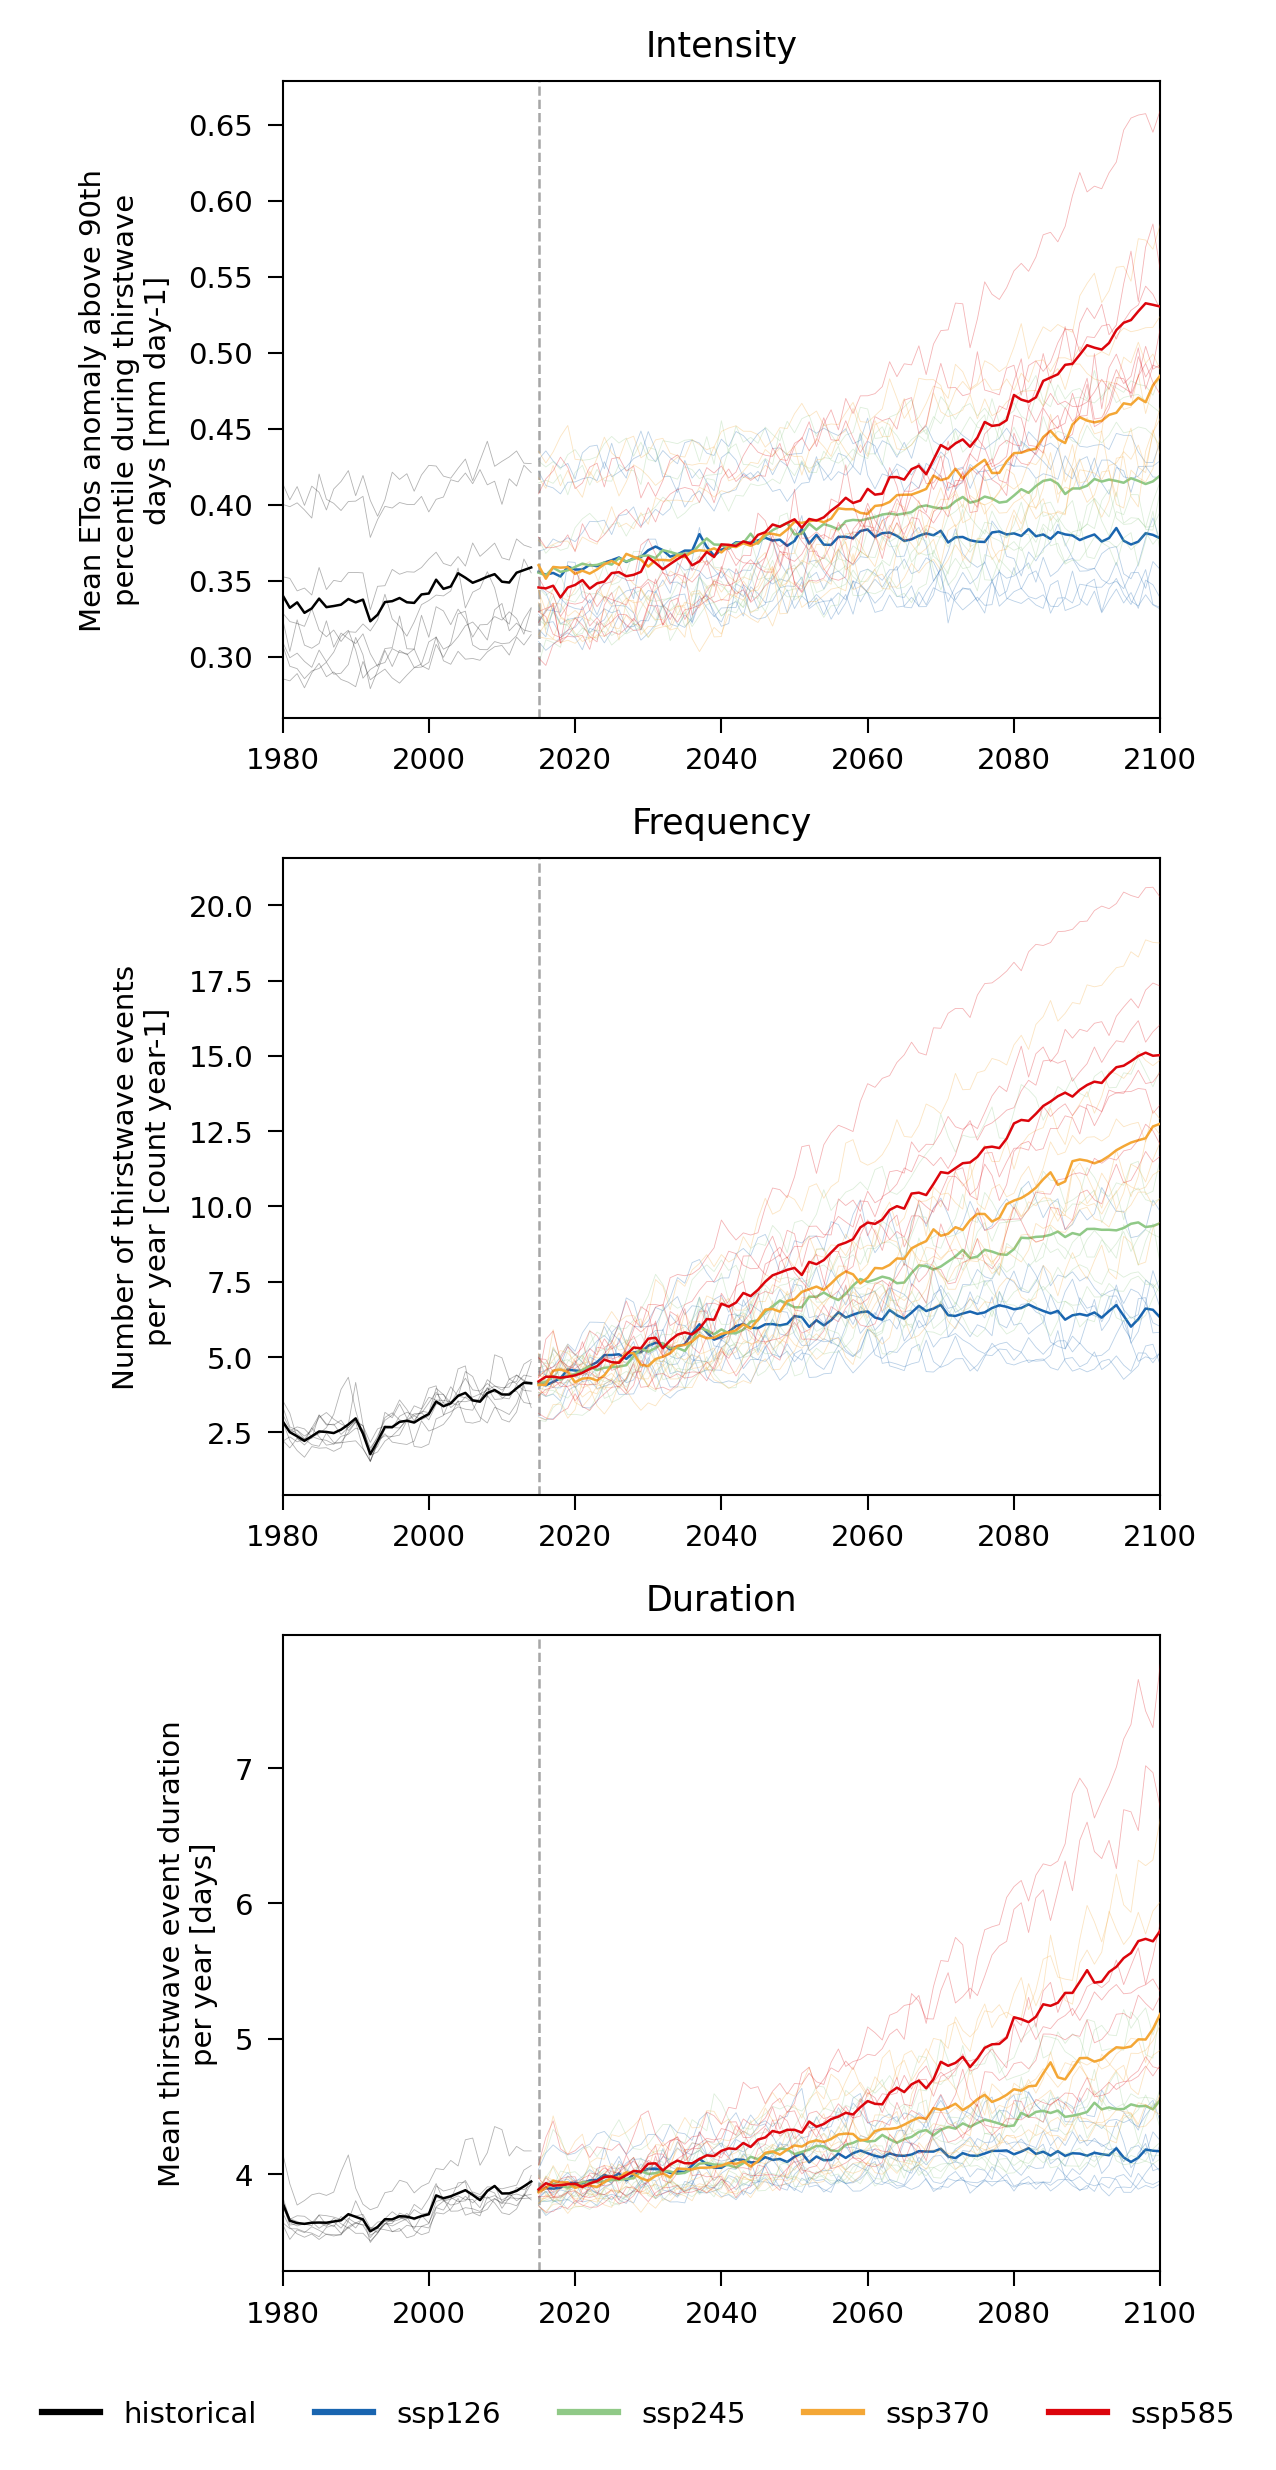

In [16]:
# Style adjustments (Nature style)
plt.style.use('nature')
mm = 1/25.4  # mm to inches
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(100*mm, 200*mm))

plot_params = { "figure.dpi": "300",
               "font.size": 7,
               "axes.labelsize": 5,
               "figure.titlesize": 7,
               "xtick.major.width": 0.5,
               "ytick.major.width": 0.5,
               }
plt.rcParams.update(plot_params)

for exp in experiments:
    style = EXPERIMENT_STYLE[exp]

    for model in models:
        try:
            ds = all_results.get(model).get(exp)
            if ds is None:
                print(f"[{model} / {exp}] ERROR loading")
                continue
            
        except Exception as e:
            print(f"[{model} / {exp}] ERROR: {e}")

        # Intensity
        intensity = intensity_all[exp][model]
        intensity.plot(ax=axes[0], color=style["color"], linewidth=style["linewidth"], zorder=style["zorder"], alpha=style["alpha"])

        # Frequency
        frequency = frequency_all[exp][model]
        frequency.plot(ax=axes[1], color=style["color"], linewidth=style["linewidth"], zorder=style["zorder"], alpha=style["alpha"])

        # Duration
        duration = duration_all[exp][model]
        duration.plot(ax=axes[2], color=style["color"], linewidth=style["linewidth"], zorder=style["zorder"], alpha=style["alpha"])

    # Plot mean of the 8 models with a thicker line
    intensity_all[exp]["mean"].plot(ax=axes[0], color=style["color"], linewidth=style["linewidth"]*3, zorder=style["zorder"], alpha=1)
    frequency_all[exp]["mean"].plot(ax=axes[1], color=style["color"], linewidth=style["linewidth"]*3, zorder=style["zorder"], alpha=1) 
    duration_all[exp]["mean"].plot(ax=axes[2], color=style["color"], linewidth=style["linewidth"]*3, zorder=style["zorder"], alpha=1) 

for ax in axes:
    ax.axvline(TRANSITION_YEAR, color="grey", linestyle="--", linewidth=0.6, alpha=0.7) # Dashed grey vertical line marking the end of the historical exp / start of the SSPs
    ax.set_xlim(*XLIM) # X axis from 1980 to 2100
    ax.set_xlabel('')

axes[0].set_title("Intensity")
axes[1].set_title("Frequency")
axes[2].set_title("Duration")

# Shared legend for the whole figure
legend_handles = [
    Line2D([0], [0], color=style["color"], linewidth=1.5, alpha=1, label=exp)
    for exp, style in EXPERIMENT_STYLE.items()
]
fig.legend(handles=legend_handles, loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.04), frameon=False)

fig.tight_layout()
#fig.subplots_adjust(wspace=0.3, hspace=0.4)

# Export to png
outdir = Path(".")
outdir.mkdir(exist_ok=True)
outpath = outdir / f"annual_thirstwave_metrics.png"
fig.savefig(outpath, dpi=300, bbox_inches="tight")
print(f"\n\tSaved figure to {outpath.resolve()}")